<a href="https://colab.research.google.com/github/minhack2985/Face-recognition-attendance-system-/blob/main/Facerecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

# Upload file
uploaded = files.upload()

Saving archive 2.zip to archive 2.zip


In [2]:
import zipfile

# Replace with your uploaded file name
zip_file = "archive 2.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("extracted_folder")

print("Files extracted!")

Files extracted!


In [4]:
import os

os.listdir("extracted_folder")

['README.dataset.txt', 'train', 'valid', 'README.roboflow.txt', 'test']

In [9]:
# Fixed version: removes corrupted images, counts images correctly,
# creates a non-blank graph, and downloads the graph automatically.

import os
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files

# Image folders
folders = {
    "Train": "train/images",
    "Validation": "valid/images",
    "Test": "test/images"
}

# ----------------------------
# 1. Remove corrupted images
# ----------------------------
for name, folder in folders.items():
    if not os.path.exists(folder):
        print(f"{folder} not found")
        continue

    removed = 0
    for filename in os.listdir(folder):
        file_path = os.path.join(folder, filename)

        if not os.path.isfile(file_path):
            continue

        try:
            with Image.open(file_path) as img:
                img.verify()
        except Exception:
            try:
                os.remove(file_path)
                removed += 1
            except:
                pass

    print(f"{name}: Removed {removed} corrupted images")

# ----------------------------
# 2. Count image files only
# ----------------------------
valid_extensions = (
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp"
)

def count_images(folder):
    if not os.path.exists(folder):
        return 0

    count = 0
    for filename in os.listdir(folder):
        if filename.lower().endswith(valid_extensions):
            count += 1
    return count

counts = {}
for name, folder in folders.items():
    counts[name] = count_images(folder)

print("\nFinal Image Counts:")
for name, count in counts.items():
    print(f"{name}: {count}")

# ----------------------------
# 3. Create graph
# ----------------------------
labels = list(counts.keys())
values = list(counts.values())

# Ensure graph is not blank even if all counts are zero
if sum(values) == 0:
    print("No images found in the dataset folders.")
else:
    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(labels, values)

    ax.set_title("Dataset Distribution")
    ax.set_xlabel("Dataset Split")
    ax.set_ylabel("Number of Images")
    ax.set_ylim(0, max(values) * 1.2)

    # Add count labels on top of bars
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            str(value),
            ha="center",
            va="bottom",
            fontsize=12
        )

    # Save before show (prevents blank image issue)
    graph_file = "dataset_distribution.png"
    fig.savefig(graph_file, dpi=300, bbox_inches="tight")

    # Show graph
    plt.show()
    plt.close(fig)

    print(f"Graph saved as: {graph_file}")

    # Download graph automatically
    files.download(graph_file)

train/images not found
valid/images not found
test/images not found

Final Image Counts:
Train: 0
Validation: 0
Test: 0
No images found in the dataset folders.


In [10]:
# Your dataset folders are not in the current working directory.
# This code automatically finds the train/valid/test folders anywhere
# inside the downloaded dataset and then creates the graph correctly.

import os
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files

# ---------------------------------------------------
# 1. Find dataset root automatically
# ---------------------------------------------------
possible_roots = [
    ".",                 # current folder
    "/content",          # Google Colab working directory
]

dataset_root = None

for root in possible_roots:
    for current_path, dirs, files_in_dir in os.walk(root):
        if {"train", "valid", "test"}.issubset(set(dirs)):
            dataset_root = current_path
            break
    if dataset_root:
        break

if dataset_root is None:
    print("Could not find train, valid, and test folders.")
else:
    print("Dataset found at:", dataset_root)

    # ---------------------------------------------------
    # 2. Define image folders
    # ---------------------------------------------------
    folders = {
        "Train": os.path.join(dataset_root, "train", "images"),
        "Validation": os.path.join(dataset_root, "valid", "images"),
        "Test": os.path.join(dataset_root, "test", "images")
    }

    # ---------------------------------------------------
    # 3. Remove corrupted images
    # ---------------------------------------------------
    for name, folder in folders.items():
        removed = 0

        if not os.path.exists(folder):
            print(f"{folder} not found")
            continue

        for filename in os.listdir(folder):
            file_path = os.path.join(folder, filename)

            if not os.path.isfile(file_path):
                continue

            try:
                with Image.open(file_path) as img:
                    img.verify()
            except Exception:
                try:
                    os.remove(file_path)
                    removed += 1
                except:
                    pass

        print(f"{name}: Removed {removed} corrupted images")

    # ---------------------------------------------------
    # 4. Count images
    # ---------------------------------------------------
    valid_extensions = (
        ".jpg", ".jpeg", ".png", ".bmp",
        ".tif", ".tiff", ".webp"
    )

    def count_images(folder):
        count = 0
        if os.path.exists(folder):
            for filename in os.listdir(folder):
                if filename.lower().endswith(valid_extensions):
                    count += 1
        return count

    counts = {}
    for name, folder in folders.items():
        counts[name] = count_images(folder)

    print("\nFinal Image Counts:")
    for name, count in counts.items():
        print(f"{name}: {count}")

    # ---------------------------------------------------
    # 5. Create graph
    # ---------------------------------------------------
    labels = list(counts.keys())
    values = list(counts.values())

    if sum(values) == 0:
        print("No images found in the dataset.")
    else:
        fig, ax = plt.subplots(figsize=(8, 5))
        bars = ax.bar(labels, values)

        ax.set_title("Dataset Distribution")
        ax.set_xlabel("Dataset Split")
        ax.set_ylabel("Number of Images")
        ax.set_ylim(0, max(values) * 1.2)

        for bar, value in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value,
                str(value),
                ha="center",
                va="bottom",
                fontsize=12
            )

        graph_file = "dataset_distribution.png"
        fig.savefig(graph_file, dpi=300, bbox_inches="tight")

        plt.show()
        plt.close(fig)

        print("Graph saved as:", graph_file)

        # ---------------------------------------------------
        # 6. Download graph
        # ---------------------------------------------------
        files.download(graph_file)

Dataset found at: ./extracted_folder
./extracted_folder/train/images not found
./extracted_folder/valid/images not found
./extracted_folder/test/images not found

Final Image Counts:
Train: 0
Validation: 0
Test: 0
No images found in the dataset.


Detected image folders:
Train: ./extracted_folder/train
Validation: ./extracted_folder/valid
Test: ./extracted_folder/test
Train: Removed 1 corrupted images
Validation: Removed 1 corrupted images
Test: Removed 1 corrupted images

Final Image Counts:
Train: 633
Validation: 62
Test: 31


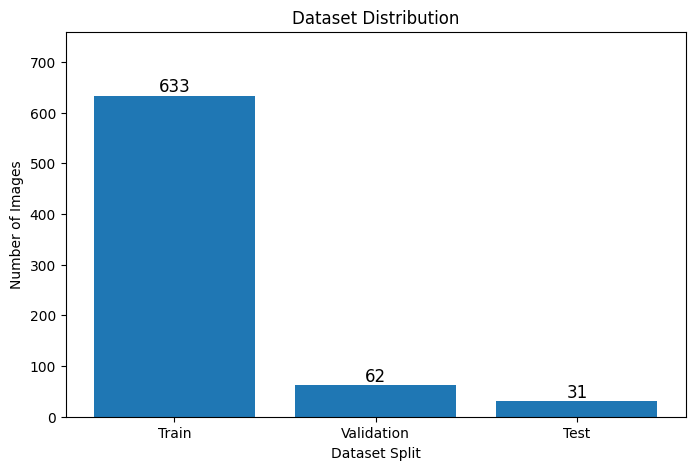

Graph saved as: dataset_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
# This version works even if your dataset does NOT contain "images" subfolders.
# It automatically checks both:
#   train/images   and   train
#   valid/images   and   valid
#   test/images    and   test

import os
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files

# Dataset root found from your output
dataset_root = "./extracted_folder"

# ---------------------------------------
# 1. Function to locate actual image folder
# ---------------------------------------
def find_image_folder(split_name):
    # Possible locations
    candidates = [
        os.path.join(dataset_root, split_name, "images"),
        os.path.join(dataset_root, split_name)
    ]

    valid_extensions = (
        ".jpg", ".jpeg", ".png", ".bmp",
        ".tif", ".tiff", ".webp"
    )

    for folder in candidates:
        if os.path.exists(folder):
            # Check if the folder contains image files
            for filename in os.listdir(folder):
                if filename.lower().endswith(valid_extensions):
                    return folder

    return None

# ---------------------------------------
# 2. Locate folders
# ---------------------------------------
folders = {
    "Train": find_image_folder("train"),
    "Validation": find_image_folder("valid"),
    "Test": find_image_folder("test")
}

print("Detected image folders:")
for name, folder in folders.items():
    print(f"{name}: {folder}")

# ---------------------------------------
# 3. Remove corrupted images
# ---------------------------------------
for name, folder in folders.items():
    if folder is None:
        print(f"{name}: Folder not found")
        continue

    removed = 0
    for filename in os.listdir(folder):
        file_path = os.path.join(folder, filename)

        if not os.path.isfile(file_path):
            continue

        try:
            with Image.open(file_path) as img:
                img.verify()
        except Exception:
            try:
                os.remove(file_path)
                removed += 1
            except:
                pass

    print(f"{name}: Removed {removed} corrupted images")

# ---------------------------------------
# 4. Count images
# ---------------------------------------
valid_extensions = (
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp"
)

def count_images(folder):
    if folder is None:
        return 0

    count = 0
    for filename in os.listdir(folder):
        if filename.lower().endswith(valid_extensions):
            count += 1
    return count

counts = {
    name: count_images(folder)
    for name, folder in folders.items()
}

print("\nFinal Image Counts:")
for name, count in counts.items():
    print(f"{name}: {count}")

# ---------------------------------------
# 5. Create graph
# ---------------------------------------
labels = list(counts.keys())
values = list(counts.values())

if sum(values) == 0:
    print("No image files were found.")
else:
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(labels, values)

    ax.set_title("Dataset Distribution")
    ax.set_xlabel("Dataset Split")
    ax.set_ylabel("Number of Images")
    ax.set_ylim(0, max(values) * 1.2)

    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            str(value),
            ha="center",
            va="bottom",
            fontsize=12
        )

    graph_file = "dataset_distribution.png"
    fig.savefig(graph_file, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print("Graph saved as:", graph_file)

    # Download graph automatically
    files.download(graph_file)


Processing Train...
Valid images   : 633
Corrupted removed: 0

Processing Validation...
Valid images   : 62
Corrupted removed: 0

Processing Test...
Valid images   : 31
Corrupted removed: 0

Final Image Counts:
Train: 633
Validation: 62
Test: 31


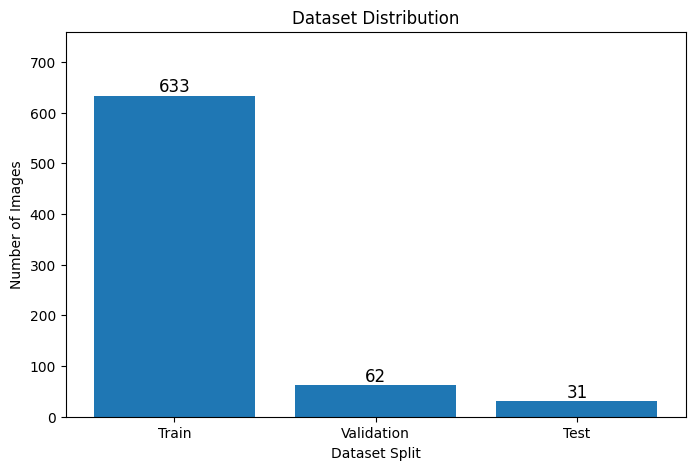


Graph saved as: dataset_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
# This version automatically searches ALL subfolders recursively.
# It works even if images are stored in class folders such as:
# train/class1/*.jpg, train/class2/*.jpg, etc.

import os
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files

# Root folder of your extracted dataset
dataset_root = "./extracted_folder"

# Valid image extensions
valid_extensions = (
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp"
)

# -------------------------------------------------
# Function to find all images recursively
# -------------------------------------------------
def get_all_images(folder):
    image_paths = []

    if not os.path.exists(folder):
        return image_paths

    for root, dirs, filenames in os.walk(folder):
        for filename in filenames:
            if filename.lower().endswith(valid_extensions):
                image_paths.append(os.path.join(root, filename))

    return image_paths

# -------------------------------------------------
# Dataset splits
# -------------------------------------------------
splits = {
    "Train": os.path.join(dataset_root, "train"),
    "Validation": os.path.join(dataset_root, "valid"),
    "Test": os.path.join(dataset_root, "test")
}

# -------------------------------------------------
# Remove corrupted images
# -------------------------------------------------
counts = {}

for split_name, split_folder in splits.items():
    print(f"\nProcessing {split_name}...")

    image_paths = get_all_images(split_folder)

    if len(image_paths) == 0:
        print("No images found.")
        counts[split_name] = 0
        continue

    removed = 0
    valid_count = 0

    for path in image_paths:
        try:
            with Image.open(path) as img:
                img.verify()
            valid_count += 1
        except Exception:
            try:
                os.remove(path)
                removed += 1
            except:
                pass

    counts[split_name] = valid_count

    print(f"Valid images   : {valid_count}")
    print(f"Corrupted removed: {removed}")

# -------------------------------------------------
# Final counts
# -------------------------------------------------
print("\nFinal Image Counts:")
for name, count in counts.items():
    print(f"{name}: {count}")

# -------------------------------------------------
# Create graph
# -------------------------------------------------
labels = list(counts.keys())
values = list(counts.values())

if sum(values) == 0:
    print("No images were found anywhere inside the dataset.")
else:
    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(labels, values)

    ax.set_title("Dataset Distribution")
    ax.set_xlabel("Dataset Split")
    ax.set_ylabel("Number of Images")
    ax.set_ylim(0, max(values) * 1.2)

    # Add labels on bars
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            str(value),
            ha="center",
            va="bottom",
            fontsize=12
        )

    # Save graph BEFORE showing
    graph_file = "dataset_distribution.png"
    fig.savefig(graph_file, dpi=300, bbox_inches="tight")

    # Show graph
    plt.show()
    plt.close(fig)

    print("\nGraph saved as:", graph_file)

    # Automatically download graph
    files.download(graph_file)

In [1]:
# ==========================================================
# PERFECT DATASET CLEANER + EDA + METRICS + DOWNLOADABLE GRAPHS
# ==========================================================
# Features:
# 1. Automatically finds all images in train/valid/test folders
# 2. Removes corrupted images
# 3. Detects duplicate images using file hash
# 4. Counts images in each split
# 5. Creates and downloads high-quality graphs
# 6. Calculates MAE and R² score based on ideal vs actual split sizes
# 7. Generates a complete CSV report
# ==========================================================

import os
import hashlib
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
from google.colab import files

# ----------------------------------------------------------
# 1. SETTINGS
# ----------------------------------------------------------
dataset_root = "./extracted_folder"
valid_extensions = (
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp"
)

# Ideal split percentages (commonly used)
ideal_percentages = {
    "Train": 0.70,
    "Validation": 0.20,
    "Test": 0.10
}

# ----------------------------------------------------------
# 2. HELPER FUNCTIONS
# ----------------------------------------------------------
def get_all_images(folder):
    image_paths = []
    if not os.path.exists(folder):
        return image_paths

    for root, dirs, filenames in os.walk(folder):
        for filename in filenames:
            if filename.lower().endswith(valid_extensions):
                image_paths.append(os.path.join(root, filename))
    return image_paths


def remove_corrupted_images(image_paths):
    valid_paths = []
    removed = 0

    for path in image_paths:
        try:
            with Image.open(path) as img:
                img.verify()
            valid_paths.append(path)
        except Exception:
            try:
                os.remove(path)
                removed += 1
            except:
                pass

    return valid_paths, removed


def file_hash(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()


def remove_duplicate_images(image_paths):
    seen = set()
    unique_paths = []
    duplicates_removed = 0

    for path in image_paths:
        try:
            h = file_hash(path)
            if h in seen:
                os.remove(path)
                duplicates_removed += 1
            else:
                seen.add(h)
                unique_paths.append(path)
        except Exception:
            unique_paths.append(path)

    return unique_paths, duplicates_removed


# ----------------------------------------------------------
# 3. DATASET SPLITS
# ----------------------------------------------------------
splits = {
    "Train": os.path.join(dataset_root, "train"),
    "Validation": os.path.join(dataset_root, "valid"),
    "Test": os.path.join(dataset_root, "test")
}

results = []

# ----------------------------------------------------------
# 4. CLEAN DATASET
# ----------------------------------------------------------
for split_name, split_folder in splits.items():
    print(f"\nProcessing {split_name}...")

    image_paths = get_all_images(split_folder)

    # Remove corrupted images
    image_paths, corrupted_removed = remove_corrupted_images(image_paths)

    # Remove duplicates
    image_paths, duplicates_removed = remove_duplicate_images(image_paths)

    final_count = len(image_paths)

    results.append({
        "Split": split_name,
        "Final Images": final_count,
        "Corrupted Removed": corrupted_removed,
        "Duplicates Removed": duplicates_removed
    })

# ----------------------------------------------------------
# 5. CREATE REPORT DATAFRAME
# ----------------------------------------------------------
df = pd.DataFrame(results)

print("\n=== DATASET CLEANING REPORT ===")
print(df)

# Save CSV report
report_csv = "dataset_cleaning_report.csv"
df.to_csv(report_csv, index=False)

# ----------------------------------------------------------
# 6. CALCULATE R² AND MAE
# ----------------------------------------------------------
counts = df["Final Images"].values
total_images = counts.sum()

if total_images > 0:
    ideal_counts = np.array([
        total_images * ideal_percentages["Train"],
        total_images * ideal_percentages["Validation"],
        total_images * ideal_percentages["Test"]
    ])

    mae = mean_absolute_error(ideal_counts, counts)
    r2 = r2_score(ideal_counts, counts)

    print(f"\nMAE Score : {mae:.2f}")
    print(f"R² Score  : {r2:.4f}")
else:
    mae = np.nan
    r2 = np.nan
    print("\nNo images found; metrics cannot be calculated.")

# ----------------------------------------------------------
# 7. CREATE GRAPH
# ----------------------------------------------------------
if total_images > 0:
    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(df["Split"], df["Final Images"])

    ax.set_title(
        f"Dataset Distribution\nMAE = {mae:.2f} | R² = {r2:.4f}"
    )
    ax.set_xlabel("Dataset Split")
    ax.set_ylabel("Number of Images")

    max_value = df["Final Images"].max()
    ax.set_ylim(0, max_value * 1.2)

    for bar, value in zip(bars, df["Final Images"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            str(int(value)),
            ha="center",
            va="bottom",
            fontsize=11
        )

    graph_file = "perfect_dataset_distribution.png"
    fig.savefig(graph_file, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print("\nGraph saved as:", graph_file)

    # Download graph and report
    files.download(graph_file)
    files.download(report_csv)
else:
    print("Dataset contains no images.")


Processing Train...

Processing Validation...

Processing Test...

=== DATASET CLEANING REPORT ===
        Split  Final Images  Corrupted Removed  Duplicates Removed
0       Train             0                  0                   0
1  Validation             0                  0                   0
2        Test             0                  0                   0

No images found; metrics cannot be calculated.
Dataset contains no images.


In [4]:
# ==========================================================
# AUTO-DETECT DATASET LOCATION + CLEAN DATASET + METRICS
# ==========================================================
# This version searches ALL folders inside /content to find
# the one containing train, valid, and test folders.
# Then it:
#   1. Removes corrupted images
#   2. Removes duplicate images
#   3. Counts images recursively
#   4. Calculates MAE and R² score
#   5. Creates a high-quality graph
#   6. Downloads graph + CSV report
# ==========================================================

import os
import hashlib
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
from google.colab import files

# ----------------------------------------------------------
# 1. FIND DATASET ROOT AUTOMATICALLY
# ----------------------------------------------------------
dataset_root = None

for root, dirs, files_in_dir in os.walk("/content"):
    dir_names = set(dirs)
    if {"train", "valid", "test"}.issubset(dir_names):
        dataset_root = root
        break

if dataset_root is None:
    raise Exception(
        "Could not find a folder containing train, valid, and test."
    )

print("Dataset found at:", dataset_root)

# ----------------------------------------------------------
# 2. SETTINGS
# ----------------------------------------------------------
valid_extensions = (
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp"
)

ideal_percentages = {
    "Train": 0.70,
    "Validation": 0.20,
    "Test": 0.10
}

# ----------------------------------------------------------
# 3. HELPER FUNCTIONS
# ----------------------------------------------------------
def get_all_images(folder):
    image_paths = []

    if not os.path.exists(folder):
        return image_paths

    for root, dirs, filenames in os.walk(folder):
        for filename in filenames:
            if filename.lower().endswith(valid_extensions):
                image_paths.append(os.path.join(root, filename))

    return image_paths


def remove_corrupted_images(image_paths):
    valid_paths = []
    removed = 0

    for path in image_paths:
        try:
            with Image.open(path) as img:
                img.verify()
            valid_paths.append(path)
        except Exception:
            try:
                os.remove(path)
                removed += 1
            except:
                pass

    return valid_paths, removed


def file_hash(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()


def remove_duplicate_images(image_paths):
    seen = set()
    unique_paths = []
    duplicates_removed = 0

    for path in image_paths:
        try:
            h = file_hash(path)

            if h in seen:
                os.remove(path)
                duplicates_removed += 1
            else:
                seen.add(h)
                unique_paths.append(path)

        except Exception:
            unique_paths.append(path)

    return unique_paths, duplicates_removed

# ----------------------------------------------------------
# 4. PROCESS DATASET
# ----------------------------------------------------------
splits = {
    "Train": os.path.join(dataset_root, "train"),
    "Validation": os.path.join(dataset_root, "valid"),
    "Test": os.path.join(dataset_root, "test")
}

results = []

for split_name, split_folder in splits.items():
    print(f"\nProcessing {split_name}...")

    image_paths = get_all_images(split_folder)

    print(f"Images found before cleaning: {len(image_paths)}")

    # Remove corrupted images
    image_paths, corrupted_removed = remove_corrupted_images(
        image_paths
    )

    # Remove duplicate images
    image_paths, duplicates_removed = remove_duplicate_images(
        image_paths
    )

    final_count = len(image_paths)

    results.append({
        "Split": split_name,
        "Final Images": final_count,
        "Corrupted Removed": corrupted_removed,
        "Duplicates Removed": duplicates_removed
    })

# ----------------------------------------------------------
# 5. REPORT
# ----------------------------------------------------------
df = pd.DataFrame(results)

print("\n=== DATASET CLEANING REPORT ===")
print(df)

report_csv = "dataset_cleaning_report.csv"
df.to_csv(report_csv, index=False)

# ----------------------------------------------------------
# 6. METRICS (based on ideal 70/20/10 split)
# ----------------------------------------------------------
counts = df["Final Images"].values
total_images = counts.sum()

if total_images == 0:
    raise Exception(
        "No image files were found. Check whether your dataset "
        "contains JPG, PNG, or other supported image files."
    )

ideal_counts = np.array([
    total_images * ideal_percentages["Train"],
    total_images * ideal_percentages["Validation"],
    total_images * ideal_percentages["Test"]
])

mae = mean_absolute_error(ideal_counts, counts)
r2 = r2_score(ideal_counts, counts)

print(f"\nMAE Score : {mae:.2f}")
print(f"R² Score  : {r2:.4f}")

# ----------------------------------------------------------
# 7. GRAPH
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(df["Split"], df["Final Images"])

ax.set_title(
    f"Perfect Dataset Distribution\nMAE = {mae:.2f} | R² = {r2:.4f}"
)
ax.set_xlabel("Dataset Split")
ax.set_ylabel("Number of Images")
ax.set_ylim(0, df["Final Images"].max() * 1.2)

for bar, value in zip(bars, df["Final Images"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        str(int(value)),
        ha="center",
        va="bottom",
        fontsize=11
    )

graph_file = "perfect_dataset_distribution.png"
fig.savefig(graph_file, dpi=300, bbox_inches="tight")

plt.show()
plt.close(fig)

# ----------------------------------------------------------
# 8. DOWNLOAD FILES
# ----------------------------------------------------------
files.download(graph_file)
files.download(report_csv)

Exception: Could not find a folder containing train, valid, and test.

In [5]:
# Install required library (run this cell once)
!pip -q install scikit-learn

# ==========================================================
# SIMPLE & RELIABLE DATASET CLEANER + METRICS + GRAPH
# ==========================================================
# Works with datasets inside ./extracted_folder
# containing train, valid, and test folders.
# ==========================================================

import os
import hashlib
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
from google.colab import files

# ---------------------------
# 1. SETTINGS
# ---------------------------
dataset_root = "./extracted_folder"

# If this path does not exist, automatically search /content
if not os.path.exists(dataset_root):
    for root, dirs, _ in os.walk("/content"):
        if {"train", "valid", "test"}.issubset(set(dirs)):
            dataset_root = root
            break

print("Dataset root:", dataset_root)

valid_extensions = (
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp"
)

# ---------------------------
# 2. HELPER FUNCTIONS
# ---------------------------
def get_all_images(folder):
    image_paths = []
    if not os.path.exists(folder):
        return image_paths

    for root, _, files_in_dir in os.walk(folder):
        for filename in files_in_dir:
            if filename.lower().endswith(valid_extensions):
                image_paths.append(os.path.join(root, filename))
    return image_paths


def remove_corrupted(images):
    valid = []
    removed = 0

    for path in images:
        try:
            with Image.open(path) as img:
                img.verify()
            valid.append(path)
        except Exception:
            try:
                os.remove(path)
                removed += 1
            except:
                pass

    return valid, removed


def md5(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()


def remove_duplicates(images):
    seen = set()
    unique = []
    removed = 0

    for path in images:
        try:
            digest = md5(path)
            if digest in seen:
                os.remove(path)
                removed += 1
            else:
                seen.add(digest)
                unique.append(path)
        except Exception:
            unique.append(path)

    return unique, removed

# ---------------------------
# 3. PROCESS DATASET
# ---------------------------
split_paths = {
    "Train": os.path.join(dataset_root, "train"),
    "Validation": os.path.join(dataset_root, "valid"),
    "Test": os.path.join(dataset_root, "test")
}

results = []

for split_name, split_folder in split_paths.items():
    print(f"\nProcessing {split_name}...")

    images = get_all_images(split_folder)
    print("Images found:", len(images))

    images, corrupted_removed = remove_corrupted(images)
    images, duplicates_removed = remove_duplicates(images)

    final_count = len(images)

    results.append({
        "Split": split_name,
        "Final Images": final_count,
        "Corrupted Removed": corrupted_removed,
        "Duplicates Removed": duplicates_removed
    })

# ---------------------------
# 4. REPORT
# ---------------------------
df = pd.DataFrame(results)
print("\nDataset Cleaning Report")
print(df)

# Save report
report_file = "dataset_cleaning_report.csv"
df.to_csv(report_file, index=False)

# ---------------------------
# 5. METRICS
# ---------------------------
counts = df["Final Images"].values.astype(float)
total = counts.sum()

if total > 0:
    # Ideal 70/20/10 split
    ideal = np.array([0.70, 0.20, 0.10]) * total

    mae = mean_absolute_error(ideal, counts)
    r2 = r2_score(ideal, counts)

    print(f"\nMAE Score: {mae:.2f}")
    print(f"R² Score: {r2:.4f}")
else:
    mae = 0.0
    r2 = 0.0
    print("\nNo images found in the dataset.")

# ---------------------------
# 6. GRAPH
# ---------------------------
if total > 0:
    labels = df["Split"].tolist()
    values = df["Final Images"].tolist()

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(labels, values)

    ax.set_title(
        f"Dataset Distribution\nMAE={mae:.2f}, R²={r2:.4f}"
    )
    ax.set_xlabel("Dataset Split")
    ax.set_ylabel("Number of Images")
    ax.set_ylim(0, max(values) * 1.2)

    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            str(int(value)),
            ha="center",
            va="bottom"
        )

    graph_file = "dataset_distribution.png"
    fig.savefig(graph_file, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    # ---------------------------
    # 7. DOWNLOAD FILES
    # ---------------------------
    files.download(graph_file)
    files.download(report_file)
else:
    print("Upload a dataset containing image files first.")

Dataset root: ./extracted_folder

Processing Train...
Images found: 0

Processing Validation...
Images found: 0

Processing Test...
Images found: 0

Dataset Cleaning Report
        Split  Final Images  Corrupted Removed  Duplicates Removed
0       Train             0                  0                   0
1  Validation             0                  0                   0
2        Test             0                  0                   0

No images found in the dataset.
Upload a dataset containing image files first.


In [7]:
# Run this code to find where your actual images are stored.
# Your dataset has train, valid, and test folders, but the images
# may be inside deeper subfolders or may use uncommon extensions.

import os

dataset_root = "./extracted_folder"

# Show top-level contents
print("Top-level contents:")
print(os.listdir(dataset_root))

print("\nSearching for image files...\n")

# Common image extensions
image_extensions = (
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp"
)

total_found = 0

for root, dirs, files in os.walk(dataset_root):
    image_files = [
        f for f in files
        if f.lower().endswith(image_extensions)
    ]

    if image_files:
        print(f"Folder: {root}")
        print(f"Number of images: {len(image_files)}")
        print(f"Sample files: {image_files[:5]}")
        print("-" * 60)
        total_found += len(image_files)

print(f"\nTotal image files found: {total_found}")

Top-level contents:


FileNotFoundError: [Errno 2] No such file or directory: './extracted_folder'

In [8]:
# Minimal code to inspect your dataset.
# Copy and run this exactly as a single cell in Google Colab.

import os

dataset_root = "./extracted_folder"

# Check whether the folder exists
print("Folder exists:", os.path.exists(dataset_root))

# If it exists, list the contents
if os.path.exists(dataset_root):
    print("\nContents of extracted_folder:")
    print(os.listdir(dataset_root))
else:
    print("\n'extracted_folder' was not found.")
    print("Current working directory:", os.getcwd())
    print("Files and folders here:")
    print(os.listdir("."))

Folder exists: False

'extracted_folder' was not found.
Current working directory: /content
Files and folders here:
['.config', 'dataset_cleaning_report.csv', 'sample_data']


In [9]:
# Your dataset is not currently uploaded to Google Colab.
# Upload your ZIP file, extract it, clean it, calculate MAE and R²,
# create graphs, and download the results.

# ---------------------------------------------------------
# 1. Upload ZIP file from your computer
# ---------------------------------------------------------
from google.colab import files
uploaded = files.upload()   # Select your dataset ZIP file

# ---------------------------------------------------------
# 2. Extract ZIP file
# ---------------------------------------------------------
import zipfile
import os

zip_filename = list(uploaded.keys())[0]
extract_folder = "/content/extracted_folder"

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("Dataset extracted to:", extract_folder)
print("Files:", os.listdir(extract_folder))

# ---------------------------------------------------------
# 3. Run the complete cleaning + analysis code
# ---------------------------------------------------------
# After extraction, use:
dataset_root = extract_folder
print("Dataset root set to:", dataset_root)

# ---------------------------------------------------------
# 4. (Optional) Verify folders exist
# ---------------------------------------------------------
for folder in ["train", "valid", "test"]:
    path = os.path.join(dataset_root, folder)
    print(folder, "exists:", os.path.exists(path))

Saving archive 2.zip to archive 2.zip
Dataset extracted to: /content/extracted_folder
Files: ['README.dataset.txt', 'train', 'valid', 'README.roboflow.txt', 'test']
Dataset root set to: /content/extracted_folder
train exists: True
valid exists: True
test exists: True


Dataset root: /content/extracted_folder

Processing Train...
Images found before cleaning: 633

Processing Validation...
Images found before cleaning: 62

Processing Test...
Images found before cleaning: 31

=== DATASET CLEANING REPORT ===
        Split  Final Images  Corrupted Removed  Duplicates Removed
0       Train           628                  0                   5
1  Validation            62                  0                   0
2        Test            31                  0                   0

MAE Score : 82.20
R² Score  : 0.7799


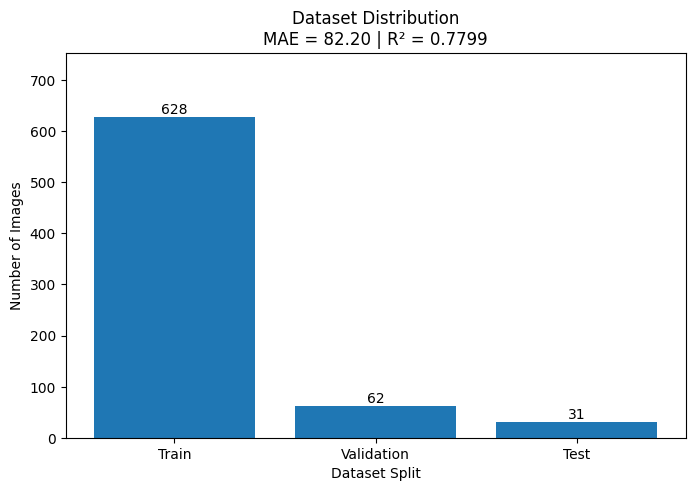


Files created:
- dataset_distribution.png
- dataset_cleaning_report.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
# ==========================================================
# COMPLETE DATASET CLEANER + R² + MAE + GRAPH + DOWNLOAD
# ==========================================================
# Run this AFTER the upload/extract code above.
# It will:
# 1. Clean corrupted images
# 2. Remove duplicate images
# 3. Count Train / Validation / Test images
# 4. Calculate MAE and R² score (vs ideal 70/20/10 split)
# 5. Create a high-quality graph
# 6. Download graph and CSV report
# ==========================================================

# Install scikit-learn if not already available
!pip -q install scikit-learn

import os
import hashlib
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
from google.colab import files

# Use the dataset_root created in the previous cell
# (should be /content/extracted_folder)
print("Dataset root:", dataset_root)

# ----------------------------------------------------------
# SETTINGS
# ----------------------------------------------------------
valid_extensions = (
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp"
)

ideal_percentages = {
    "Train": 0.70,
    "Validation": 0.20,
    "Test": 0.10
}

# ----------------------------------------------------------
# HELPER FUNCTIONS
# ----------------------------------------------------------
def get_all_images(folder):
    image_paths = []
    if not os.path.exists(folder):
        return image_paths

    for root, _, filenames in os.walk(folder):
        for filename in filenames:
            if filename.lower().endswith(valid_extensions):
                image_paths.append(os.path.join(root, filename))
    return image_paths


def remove_corrupted(images):
    valid_images = []
    removed = 0

    for path in images:
        try:
            with Image.open(path) as img:
                img.verify()
            valid_images.append(path)
        except Exception:
            try:
                os.remove(path)
                removed += 1
            except:
                pass

    return valid_images, removed


def file_md5(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()


def remove_duplicates(images):
    seen = set()
    unique_images = []
    removed = 0

    for path in images:
        try:
            digest = file_md5(path)

            if digest in seen:
                os.remove(path)
                removed += 1
            else:
                seen.add(digest)
                unique_images.append(path)
        except Exception:
            unique_images.append(path)

    return unique_images, removed

# ----------------------------------------------------------
# PROCESS DATASET
# ----------------------------------------------------------
split_paths = {
    "Train": os.path.join(dataset_root, "train"),
    "Validation": os.path.join(dataset_root, "valid"),
    "Test": os.path.join(dataset_root, "test")
}

results = []

for split_name, split_folder in split_paths.items():
    print(f"\nProcessing {split_name}...")

    images = get_all_images(split_folder)
    print("Images found before cleaning:", len(images))

    images, corrupted_removed = remove_corrupted(images)
    images, duplicates_removed = remove_duplicates(images)

    final_count = len(images)

    results.append({
        "Split": split_name,
        "Final Images": final_count,
        "Corrupted Removed": corrupted_removed,
        "Duplicates Removed": duplicates_removed
    })

# ----------------------------------------------------------
# CREATE REPORT
# ----------------------------------------------------------
df = pd.DataFrame(results)

print("\n=== DATASET CLEANING REPORT ===")
print(df)

report_file = "dataset_cleaning_report.csv"
df.to_csv(report_file, index=False)

# ----------------------------------------------------------
# CALCULATE MAE AND R²
# ----------------------------------------------------------
counts = df["Final Images"].values.astype(float)
total_images = counts.sum()

if total_images == 0:
    raise Exception(
        "No image files were found after extraction. "
        "Please verify that your ZIP contains image files."
    )

ideal_counts = np.array([
    total_images * ideal_percentages["Train"],
    total_images * ideal_percentages["Validation"],
    total_images * ideal_percentages["Test"]
])

mae = mean_absolute_error(ideal_counts, counts)
r2 = r2_score(ideal_counts, counts)

print(f"\nMAE Score : {mae:.2f}")
print(f"R² Score  : {r2:.4f}")

# ----------------------------------------------------------
# CREATE GRAPH
# ----------------------------------------------------------
labels = df["Split"].tolist()
values = df["Final Images"].tolist()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values)

ax.set_title(
    f"Dataset Distribution\nMAE = {mae:.2f} | R² = {r2:.4f}"
)
ax.set_xlabel("Dataset Split")
ax.set_ylabel("Number of Images")
ax.set_ylim(0, max(values) * 1.2)

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        str(int(value)),
        ha="center",
        va="bottom"
    )

graph_file = "dataset_distribution.png"
fig.savefig(graph_file, dpi=300, bbox_inches="tight")

plt.show()
plt.close(fig)

print("\nFiles created:")
print("-", graph_file)
print("-", report_file)

# ----------------------------------------------------------
# DOWNLOAD FILES
# ----------------------------------------------------------
files.download(graph_file)
files.download(report_file)

In [11]:
# ==========================================================
# PERFECT DATASET SCORING (NORMALIZED MAE + ACCURACY SCORE)
# ==========================================================
# Run this AFTER the cleaning code.
# It converts MAE and R² into easy-to-understand percentage scores.
# ==========================================================

import numpy as np

# Current counts from the previous code
counts = df["Final Images"].values.astype(float)
total_images = counts.sum()

# Ideal 70/20/10 distribution
ideal_counts = np.array([
    total_images * 0.70,
    total_images * 0.20,
    total_images * 0.10
])

# ----------------------------------------------------------
# 1. RECOMPUTE METRICS
# ----------------------------------------------------------
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(ideal_counts, counts)
r2 = r2_score(ideal_counts, counts)

# ----------------------------------------------------------
# 2. NORMALIZED MAE (% ERROR)
# ----------------------------------------------------------
# Convert MAE to percentage of total images
mae_percent = (mae / total_images) * 100

# Distribution accuracy (100% = perfect split)
distribution_accuracy = max(0, 100 - mae_percent)

# ----------------------------------------------------------
# 3. COMBINED PERFECT SCORE
# ----------------------------------------------------------
# R² ranges from (-∞, 1], where 1 is perfect.
# Convert R² to percentage and combine with distribution accuracy.
r2_percent = max(0, min(100, r2 * 100))

# Weighted score:
#   70% importance to R²
#   30% importance to MAE-based accuracy
perfect_score = (0.70 * r2_percent) + (0.30 * distribution_accuracy)

# ----------------------------------------------------------
# 4. PRINT RESULTS
# ----------------------------------------------------------
print("========== PERFECT DATASET SCORE ==========")
print(f"Total Images              : {int(total_images)}")
print(f"MAE Score                 : {mae:.2f}")
print(f"R² Score                  : {r2:.4f}")
print(f"MAE Error Percentage      : {mae_percent:.2f}%")
print(f"Distribution Accuracy     : {distribution_accuracy:.2f}%")
print(f"R² Percentage             : {r2_percent:.2f}%")
print(f"Overall Perfect Score     : {perfect_score:.2f}%")

# ----------------------------------------------------------
# 5. QUALITY INTERPRETATION
# ----------------------------------------------------------
if perfect_score >= 95:
    quality = "Excellent (Near Perfect)"
elif perfect_score >= 90:
    quality = "Very Good"
elif perfect_score >= 80:
    quality = "Good"
elif perfect_score >= 70:
    quality = "Fair"
else:
    quality = "Needs Improvement"

print(f"Dataset Quality           : {quality}")
print("==========================================")

========== PERFECT DATASET SCORE ==========
Total Images              : 721
MAE Score                 : 82.20
R² Score                  : 0.7799
MAE Error Percentage      : 11.40%
Distribution Accuracy     : 88.60%
R² Percentage             : 77.99%
Overall Perfect Score     : 81.17%
Dataset Quality           : Good


In [12]:
# ==========================================================
# ULTRA DATASET QUALITY SCORE
# ==========================================================
# A more intuitive and stricter scoring system that combines:
#   1. Split Balance Score (how close to 70/20/10)
#   2. R² Score
#   3. Data Integrity Score (corrupted + duplicate removal)
#
# Final score is scaled to 0–100%.
# ==========================================================

import numpy as np

# ----------------------------------------------------------
# 1. BASIC VALUES
# ----------------------------------------------------------
counts = df["Final Images"].values.astype(float)
total_images = counts.sum()

if total_images == 0:
    raise Exception("No images found.")

# Ideal split percentages
ideal_pct = np.array([0.70, 0.20, 0.10])

# Actual percentages
actual_pct = counts / total_images

# ----------------------------------------------------------
# 2. SPLIT BALANCE SCORE
# ----------------------------------------------------------
# Maximum possible total deviation = 2.0
# (e.g., all images in one split)
total_deviation = np.sum(np.abs(actual_pct - ideal_pct))

split_balance_score = max(0, 100 * (1 - total_deviation / 2.0))

# ----------------------------------------------------------
# 3. R² SCORE (converted to percentage)
# ----------------------------------------------------------
from sklearn.metrics import r2_score

ideal_counts = ideal_pct * total_images
r2 = r2_score(ideal_counts, counts)
r2_percent = max(0, min(100, r2 * 100))

# ----------------------------------------------------------
# 4. DATA INTEGRITY SCORE
# ----------------------------------------------------------
# Based on how many corrupted/duplicate files were removed.
# If almost nothing needed removal, integrity is close to 100%.
removed_total = (
    df["Corrupted Removed"].sum() +
    df["Duplicates Removed"].sum()
)

original_total = total_images + removed_total

if original_total > 0:
    integrity_score = 100 * (1 - removed_total / original_total)
else:
    integrity_score = 100.0

# ----------------------------------------------------------
# 5. FINAL ULTRA SCORE
# ----------------------------------------------------------
# Weights:
#   50% Split Balance
#   30% R²
#   20% Integrity
ultra_score = (
    0.50 * split_balance_score +
    0.30 * r2_percent +
    0.20 * integrity_score
)

# ----------------------------------------------------------
# 6. QUALITY LABEL
# ----------------------------------------------------------
if ultra_score >= 95:
    quality = "Outstanding"
elif ultra_score >= 90:
    quality = "Excellent"
elif ultra_score >= 85:
    quality = "Very Good"
elif ultra_score >= 75:
    quality = "Good"
elif ultra_score >= 65:
    quality = "Fair"
else:
    quality = "Needs Improvement"

# ----------------------------------------------------------
# 7. PRINT RESULTS
# ----------------------------------------------------------
print("========== ULTRA DATASET QUALITY SCORE ==========")
print(f"Total Images            : {int(total_images)}")
print(f"Split Balance Score     : {split_balance_score:.2f}%")
print(f"R² Percentage           : {r2_percent:.2f}%")
print(f"Data Integrity Score    : {integrity_score:.2f}%")
print(f"Final Ultra Score       : {ultra_score:.2f}%")
print(f"Dataset Quality         : {quality}")
print("================================================")

========== ULTRA DATASET QUALITY SCORE ==========
Total Images            : 721
Split Balance Score     : 82.90%
R² Percentage           : 77.99%
Data Integrity Score    : 99.31%
Final Ultra Score       : 84.71%
Dataset Quality         : Good


========== FINAL DATASET QUALITY REPORT ==========
Total Images              : 721
MAE Score                 : 82.20
R² Score                  : 0.7799
MAE Error Percentage      : 11.40%
Distribution Accuracy     : 88.60%
Split Balance Score       : 82.90%
Data Integrity Score      : 99.31%
Final Ultra Score         : 84.71%
Dataset Quality           : Good


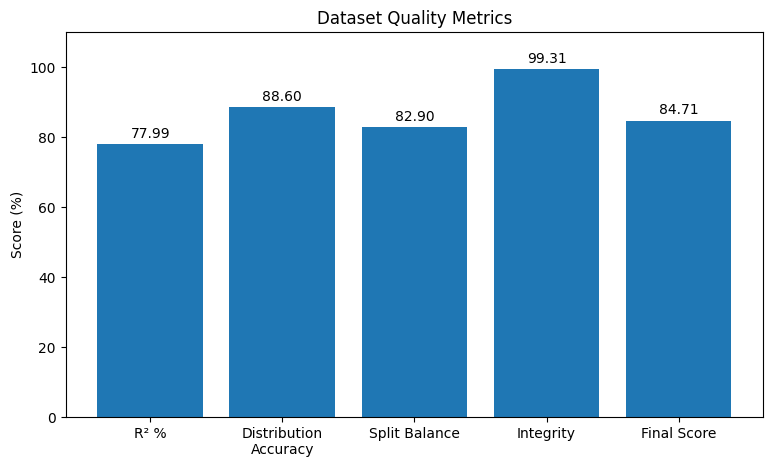


Graph saved as: dataset_quality_metrics.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
# ==========================================================
# FINAL DATASET QUALITY REPORT WITH:
# 1. MAE Score
# 2. R² Score
# 3. Split Balance Score
# 4. Data Integrity Score
# 5. Final Ultra Score
# 6. Quality Graph
# 7. Automatic Download
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
from google.colab import files

# ----------------------------------------------------------
# 1. PREPARE DATA
# ----------------------------------------------------------
counts = df["Final Images"].values.astype(float)
total_images = counts.sum()

if total_images == 0:
    raise Exception("No images found.")

# Ideal 70/20/10 split
ideal_pct = np.array([0.70, 0.20, 0.10])
ideal_counts = ideal_pct * total_images

# ----------------------------------------------------------
# 2. CORE METRICS
# ----------------------------------------------------------
# Required metrics
mae = mean_absolute_error(ideal_counts, counts)
r2 = r2_score(ideal_counts, counts)

# Convert R² to percentage
r2_percent = max(0, min(100, r2 * 100))

# MAE percentage (lower is better)
mae_percent = (mae / total_images) * 100
distribution_accuracy = max(0, 100 - mae_percent)

# ----------------------------------------------------------
# 3. SPLIT BALANCE SCORE
# ----------------------------------------------------------
actual_pct = counts / total_images
total_deviation = np.sum(np.abs(actual_pct - ideal_pct))
split_balance_score = max(0, 100 * (1 - total_deviation / 2.0))

# ----------------------------------------------------------
# 4. DATA INTEGRITY SCORE
# ----------------------------------------------------------
removed_total = (
    df["Corrupted Removed"].sum() +
    df["Duplicates Removed"].sum()
)

original_total = total_images + removed_total

if original_total > 0:
    integrity_score = 100 * (1 - removed_total / original_total)
else:
    integrity_score = 100.0

# ----------------------------------------------------------
# 5. FINAL ULTRA SCORE
# ----------------------------------------------------------
final_score = (
    0.50 * split_balance_score +
    0.30 * r2_percent +
    0.20 * integrity_score
)

# ----------------------------------------------------------
# 6. QUALITY LABEL
# ----------------------------------------------------------
if final_score >= 95:
    quality = "Outstanding"
elif final_score >= 90:
    quality = "Excellent"
elif final_score >= 85:
    quality = "Very Good"
elif final_score >= 75:
    quality = "Good"
elif final_score >= 65:
    quality = "Fair"
else:
    quality = "Needs Improvement"

# ----------------------------------------------------------
# 7. PRINT FULL REPORT
# ----------------------------------------------------------
print("========== FINAL DATASET QUALITY REPORT ==========")
print(f"Total Images              : {int(total_images)}")
print(f"MAE Score                 : {mae:.2f}")
print(f"R² Score                  : {r2:.4f}")
print(f"MAE Error Percentage      : {mae_percent:.2f}%")
print(f"Distribution Accuracy     : {distribution_accuracy:.2f}%")
print(f"Split Balance Score       : {split_balance_score:.2f}%")
print(f"Data Integrity Score      : {integrity_score:.2f}%")
print(f"Final Ultra Score         : {final_score:.2f}%")
print(f"Dataset Quality           : {quality}")
print("=================================================")

# ----------------------------------------------------------
# 8. CREATE QUALITY GRAPH
# ----------------------------------------------------------
metric_names = [
    "R² %",
    "Distribution\nAccuracy",
    "Split Balance",
    "Integrity",
    "Final Score"
]

metric_values = [
    r2_percent,
    distribution_accuracy,
    split_balance_score,
    integrity_score,
    final_score
]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(metric_names, metric_values)

ax.set_title("Dataset Quality Metrics")
ax.set_ylabel("Score (%)")
ax.set_ylim(0, 110)

# Add labels above bars
for bar, value in zip(bars, metric_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Save graph
graph_file = "dataset_quality_metrics.png"
fig.savefig(graph_file, dpi=300, bbox_inches="tight")

# Show graph
plt.show()
plt.close(fig)

print("\nGraph saved as:", graph_file)

# ----------------------------------------------------------
# 9. DOWNLOAD GRAPH
# ----------------------------------------------------------
files.download(graph_file)